In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyETo

import pySAFER
print(f"Location of the package: {pySAFER.__file__}")
print(f"pySAFER.py exist or not: {os.path.exists(os.path.join(os.path.dirname(pySAFER.__file__), 'pySAFER.py'))}")

Location of the package: C:\GitHub\pySAFER\src\pySAFER\__init__.py
pySAFER.py exist or not: True


In [2]:
file_point_sample = r"C:\GitHub\pySAFER\Examples\point_samples.txt"
df = pd.read_csv(file_point_sample, sep='\t', parse_dates=['date'])
# display(df.head(3))

year = df['year']
doy = df['doy']
lat = df['lat']
tmax = df['Tmax']
tmin = df['Tmin']
red = df['red']
nir = df['nir']
elevation = df['elevation']

In [3]:
df['eto'] = pyETo.hargreaves(
    t_min=df['Tmin'],
    t_max=df['Tmax'],
    latitude=df['lat'],
    doy=df['doy'],
    year=df['year']
)
eto = df['eto']
display(df)

,date,year,doy,lat,Tmax,Tmin,red,nir,elevation,eto
0,2025-05-01,2025,121,37.365888,38.0,21.2,0.03,0.36,65,6.944645
1,2025-05-02,2025,122,37.365888,38.1,21.3,0.03,0.36,65,6.986286
2,2025-05-03,2025,123,37.365888,38.2,21.4,0.03,0.36,65,7.027499
3,2025-05-04,2025,124,37.365888,38.3,21.5,0.03,0.36,65,7.068280
4,2025-05-05,2025,125,37.365888,38.4,21.6,0.03,0.36,65,7.108622
5,2025-05-06,2025,126,37.365888,38.5,21.7,0.03,0.36,65,7.148519
6,2025-05-07,2025,127,37.365888,38.6,21.8,0.03,0.36,65,7.187967
7,2025-05-08,2025,128,37.365888,38.7,21.9,0.03,0.36,65,7.226960
8,2025-05-09,2025,129,37.365888,38.8,22.0,0.03,0.36,65,7.265493
9,2025-05-10,2025,130,37.365888,38.9,22.1,0.03,0.36,65,7.303562


In [7]:
df['ra'] = pySAFER.calc_ra(lat, doy, year)
ra = df['ra']
df['rs_est'] = pySAFER.calc_incoming_solar_radiation(ra, rs_obs=None, tmax=tmax, tmin=tmin, coastal=True)
rs_est = df['rs_est']
df['albedo'] = pySAFER.calc_albedo(red, nir, method='R_NIR')
albedo = df['albedo']
df['r_reflect'] = pySAFER.calc_up_shortwave(rs_est, albedo, r_up_obs=None)
r_reflect = df['r_reflect']
df['rn_est'] = pySAFER.calc_r_net(rs_est, ra, albedo, tmax, tmin, rn_obs=None, para_c=6.99, para_d=39.93)
rn_est = df['rn_est']
df['g_est'] = pySAFER.calc_flux_g(rn_est, albedo, method='paras_2019', g_obs=None)
g_est = df['g_est']
df['ndvi'] = pySAFER.calc_ndvi(red, nir)
ndvi = df['ndvi']
df['le_est'], df['h_est'], df['et_fr'] = pySAFER.calc_flux_le_h(ndvi, albedo, rs_est, ra, 
                                                                tmax, tmin, 
                                                                rn_est, g_est,
                                                                eto, 
                                                                p=None, elevation=elevation)
le_est = df['le_est']
h_est = df['h_est']
display(df.head(3))

c:\tools\Anaconda\envs\delete_safer\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,date,year,doy,lat,Tmax,Tmin,red,nir,elevation,eto,ra,rs_est,albedo,r_reflect,rn_est,g_est,ndvi,le_est,h_est,et_fr
0,2025-05-01,2025,121,37.365888,38.0,21.2,0.03,0.36,65,6.944645,38.091586,29.664518,0.1427,4.233127,14.196450,0.589033,0.846154,2.298928,11.308489,0.135117
1,2025-05-02,2025,122,37.365888,38.1,21.3,0.03,0.36,65,6.986286,38.239313,29.779563,0.1427,4.249544,14.248045,0.591174,0.846154,2.282600,11.374271,0.133357
2,2025-05-03,2025,123,37.365888,38.2,21.4,0.03,0.36,65,7.027499,38.384086,29.892308,0.1427,4.265632,14.297668,0.593233,0.846154,2.266599,11.437836,0.131646


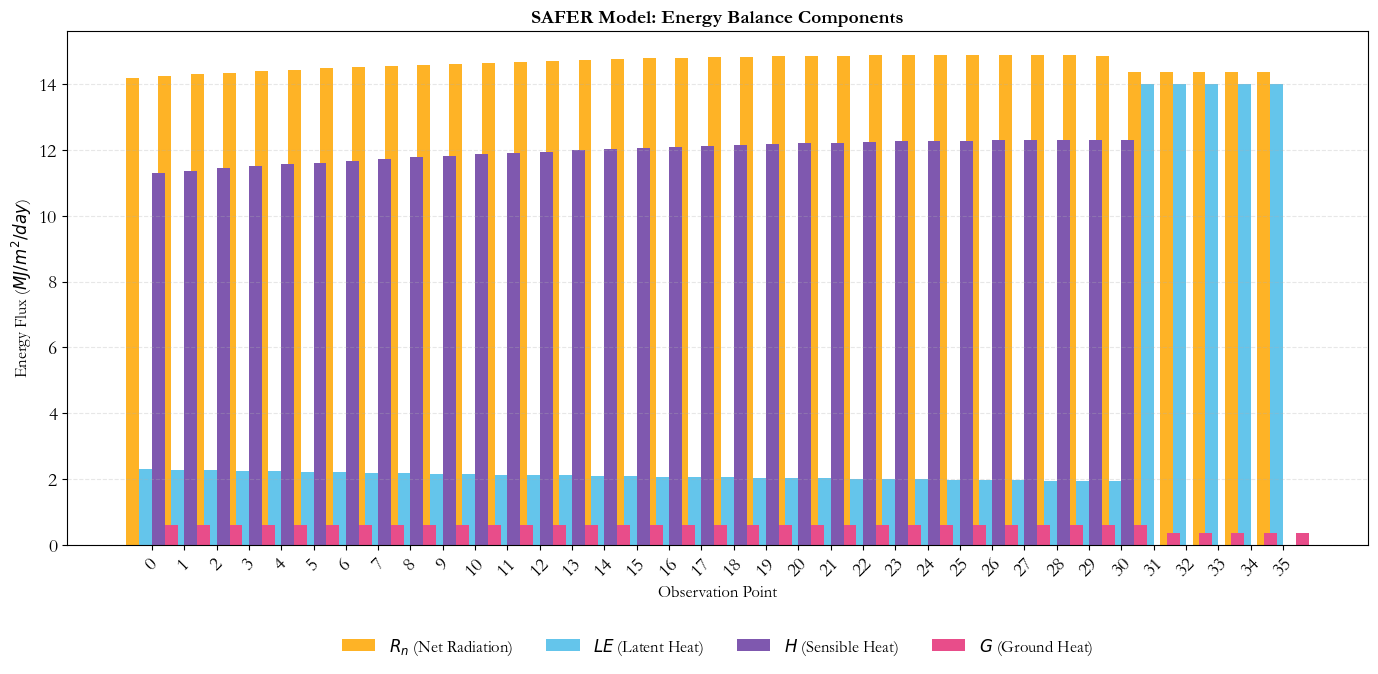

In [8]:
# Please change the size of the figure as your needs
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Garamond", "EB Garamond", "Times New Roman"],
    "font.size": 14
})

def plot_safer_energy_components(df):
    """
    Only showing energy components!
    """
    indices = df.index
    n_points = len(df)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    width = 0.4    
    # The unit used is MJ/m2/day
    ax.bar(indices - 1.5*width, df['rn_est'], width, label='$R_n$ (Net Radiation)', color='#feb326') 
    ax.bar(indices - 0.5*width, df['le_est'], width, label='$LE$ (Latent Heat)', color='#64c5eb')
    ax.bar(indices + 0.5*width, df['h_est'],  width, label='$H$ (Sensible Heat)', color='#7f58af')
    ax.bar(indices + 1.5*width, df['g_est'],  width, label='$G$ (Ground Heat)', color='#e84d8a')

    ax.set_ylabel('Energy Flux ($MJ/m^2/day$)', fontsize=12)
    ax.set_xlabel('Observation Point', fontsize=12)
    ax.set_title('SAFER Model: Energy Balance Components', fontsize=14, fontweight='bold')
    
    ax.set_xticks(indices)
    if n_points > 20:
        ax.tick_params(axis='x', rotation=45)

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
              ncol=4, frameon=False, fontsize=12)

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    
    plt.show()

plot_safer_energy_components(df)